In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
X = df_exclude_object.iloc[:,:-1]
y = df_exclude_object.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=7600, solver='lbfgs')

In [ ]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=7600)

In [ ]:
predictions = logmodel.predict(X_test)

In [ ]:
#LinearRegression max iter 7600, data belum dibalance
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96    155457
           1       0.19      0.02      0.03     11127

    accuracy                           0.93    166584
   macro avg       0.56      0.51      0.50    166584
weighted avg       0.88      0.93      0.90    166584



In [ ]:
#LinearRegression max iter 3000, data belum dibalance
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96    155457
           1       0.19      0.02      0.04     11127

    accuracy                           0.93    166584
   macro avg       0.56      0.51      0.50    166584
weighted avg       0.88      0.93      0.90    166584



#Dataset ternyata imbalanced


In [ ]:
y.value_counts()

0    517582
1     37696
Name: Label, dtype: int64

<AxesSubplot:xlabel='Label', ylabel='count'>

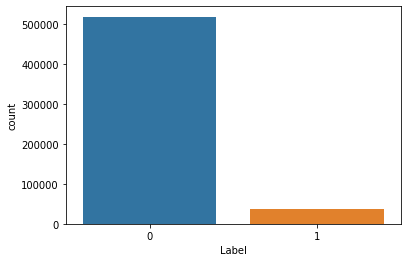

In [ ]:
sns.countplot(x='Label', data=df_exclude_object)

<AxesSubplot:xlabel='traffic_category', ylabel='count'>

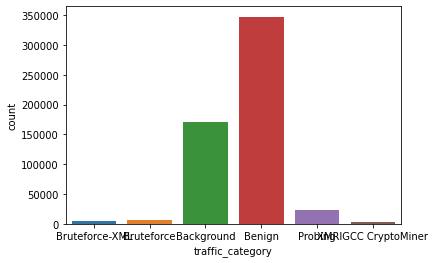

In [ ]:
sns.countplot(x='traffic_category', data=df)

In [ ]:
from collections import Counter
#https://towardsdatascience.com/how-to-balance-a-dataset-in-python-36dff9d12704
print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")

Training target statistics: Counter({0: 362125, 1: 26569})
Testing target statistics: Counter({0: 155457, 1: 11127})


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
under_sampler = RandomUnderSampler(random_state=42)
X_res, y_res = under_sampler.fit_resample(X_train, y_train)
print(f"Training target statistics: {Counter(y_res)}")
print(f"Testing target statistics: {Counter(y_test)}")

Training target statistics: Counter({0: 26569, 1: 26569})
Testing target statistics: Counter({0: 155457, 1: 11127})


In [ ]:
logmodel.fit(X_res, y_res)

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=7600)

In [ ]:
predictions = logmodel.predict(X_test)

In [ ]:
#LinearRegression max iter 7600, data dibalance
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88    155457
           1       0.24      0.98      0.39     11127

    accuracy                           0.79    166584
   macro avg       0.62      0.88      0.63    166584
weighted avg       0.95      0.79      0.84    166584



In [ ]:
#LinearRegression max iter 3000, data dibalance
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88    155457
           1       0.24      0.98      0.39     11127

    accuracy                           0.79    166584
   macro avg       0.62      0.88      0.63    166584
weighted avg       0.95      0.79      0.84    166584



In [ ]:
from imblearn.under_sampling import NearMiss
under_sampler = NearMiss()
X_res, y_res = under_sampler.fit_resample(X_train, y_train)
print(f"Training target statistics: {Counter(y_res)}")
print(f"Testing target statistics: {Counter(y_test)}")

Training target statistics: Counter({0: 26569, 1: 26569})
Testing target statistics: Counter({0: 155457, 1: 11127})


#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test, predictions)

In [ ]:
confusion_matrix(y_test, predictions)

array([[121091,  34366],
       [   178,  10949]])

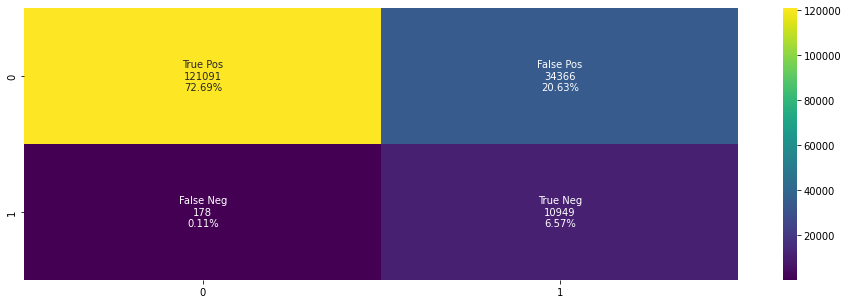

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predictions)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

#Pakai Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

In [ ]:

k_folds = KFold(n_splits = 10)

scores = cross_val_score(logmodel, X, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che

Cross Validation Scores:  [0.79770566 0.99652428 0.99747875 0.99511958 0.99027518 0.989915
 0.98586299 0.96999712 0.9912475  0.51956706]
Average CV Score:  0.9233693106442853
Number of CV Scores used in Average:  10


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
